In [1]:
%cd ../..
%env NEPTUNE_API_TOKEN="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI1MGUyNWNlYi1jYzlkLTQ4NjUtYjMxYi0yMWNlNDJiY2UwNzYifQ=="

/home/jj/Research/ConceptualSensitivityRegularization
env: NEPTUNE_API_TOKEN="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI1MGUyNWNlYi1jYzlkLTQ4NjUtYjMxYi0yMWNlNDJiY2UwNzYifQ=="


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from csr.module.utils.notebookutils import NeptuneViewer
pd.options.display.float_format = '{:,.4f}'.format

/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


# 1. Get DataFrame from Neptune project

In [4]:
project_name = '240401CatDog'
df = NeptuneViewer.get_neptune_dataframe('smoothAttributionPrior', project_name)
print('-'*20)
print(len(df))

cktp_list = df.query('module_name == "CGR"')['g_ckpt_path'].unique()
for key, module_name in zip(['svm', 'signal', 'last'], ['RRC-SVM', 'RRC-Signal', 'CGR']):
    ckpt = [i for i in cktp_list if key in i][0]
    idx = df.query('g_ckpt_path == @ckpt').index
    df.loc[idx, 'module_name'] = module_name

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/smoothAttributionPrior/240401CatDog/


Fetching table...: 0 [00:00, ?/s]

[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/smoothAttributionPrior/240401CatDog/metadata
--------------------
240


In [38]:
def mean_std(x):
    return f'{100*x.mean():.3f}+{100*x.std():.3f}'

def get_best_index(df, var_list, metric):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    idx = df_mean.reset_index().groupby(['minor_ratio']).idxmax()[metric].dropna()
    return idx

def get_mean_with_given_index(df, var_list, metric, idx):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    return df_mean.reset_index().loc[idx].set_index('minor_ratio')[metric]

def get_std_with_given_index(df, var_list, metric, idx):
    df_std = df.groupby(var_list)[metric].std().sort_index()
    return df_std.reset_index().loc[idx].set_index('minor_ratio')[metric]

def sort_and_query(df, sort_by, query):
    df_temp = df.sort_values(by=sort_by)
    df_temp = df_temp.query(query)
    return df_temp

def get_wga(df, module_name):
    df_query = df.query('model == "convnext_t" and module_name == @module_name')

    ban_list = ['lr_history']
    var_list = (df_query.nunique() >= 2) & (df_query.nunique() <= 10)
    var_list = [i for i in df.columns[var_list] if 'acc' not in i and i not in ban_list]
    

    expected_length = 1
    print(var_list)
    for i in var_list:
        print(i, df_query[i].nunique(), end=', ')
        expected_length *= df_query[i].nunique()
    print()
    print(f'Expected {expected_length} but got {len(df_query)}')

    idx = get_best_index(df_query, var_list, 'valid_valid_best_worst_acc')

    best_mean = get_mean_with_given_index(df_query, var_list, 'test_worst_acc', idx)
    best_std = get_std_with_given_index(df_query, var_list, 'test_worst_acc', idx)
    test_acc_mean = get_mean_with_given_index(df_query, var_list, 'test_acc', idx)
    test_acc_std = get_std_with_given_index(df_query, var_list, 'test_acc', idx)

    return best_mean, best_std, test_acc_mean, test_acc_std

['batch_size_train', 'data_seed', 'learning_rate', 'minor_ratio', 'set_last_layer']
batch_size_train 2, data_seed 3, learning_rate 4, minor_ratio 2, set_last_layer 2, 
Expected 96 but got 96
['data_seed', 'lamb_cs', 'minor_ratio', 'model_path']
data_seed 3, lamb_cs 8, minor_ratio 2, model_path 6, 
Expected 288 but got 48
['data_seed', 'lamb_cs', 'minor_ratio', 'model_path']
data_seed 3, lamb_cs 8, minor_ratio 2, model_path 6, 
Expected 288 but got 48
['data_seed', 'lamb_cs', 'minor_ratio', 'model_path']
data_seed 3, lamb_cs 8, minor_ratio 2, model_path 6, 
Expected 288 but got 48


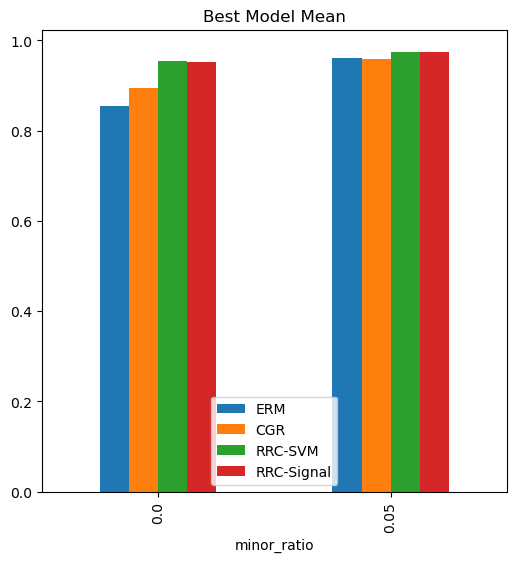

In [39]:
module_list = ['ERM', 'CGR', 'RRC-SVM', 'RRC-Signal']

# get best_mean std and plot
best_mean_list = []
best_std_list = []
for module_name in module_list:
    best_mean, best_std, test_acc_mean, test_acc_std = get_wga(df, module_name)
    best_mean_list.append(best_mean)
    best_std_list.append(best_std)

fig, ax = plt.subplots(1,1, figsize=(6,6))

best_model_mean = pd.concat(best_mean_list, axis=1)
best_model_mean.columns = module_list

# plot best model mean
best_model_mean.plot(kind='bar', yerr=pd.concat(best_std_list, axis=1), ax=ax, capsize=5)
ax.set_title('Best Model Mean')
plt.show()

